## Temporal Stability Analysis of LLM Responses
### Investigating Trajectory Features and Clustering

## Data Loading

In [ ]:
# ── SECTION 1: Load data ──────────────────────────────────
import pandas as pd
import numpy as np
from scipy.stats import linregress

df = pd.read_csv("lexical_similarity_results.csv")


## Feature Engineering

In [ ]:
# ── SECTION 2: Build trajectory features (9 features, no threshold) ──
trajectory_features = []

for (model, prompt_id), traj in df.groupby(["model", "prompt_id"]):
    traj = traj.sort_values("day_1")
    semantic = traj["similarity"].to_numpy()
    lexical  = traj["lexical_similarity"].to_numpy()
    daily_change = np.diff(semantic)
    slope, *_ = linregress(np.arange(len(semantic)), semantic)

    trajectory_features.append({
        "model":    model,
        "prompt_id": prompt_id,
        "mean_semantic_similarity":   semantic.mean(),
        "std_semantic_similarity":    semantic.std(),
        "mean_lexical_similarity":    lexical.mean(),
        "semantic_lexical_gap":       (semantic - lexical).mean(),
        "mean_absolute_daily_change": np.mean(np.abs(daily_change)),
        "largest_drop":               daily_change.min(),
        "largest_recovery":           daily_change.max(),
        "daily_change_std":           daily_change.std(),
        "trend":                      slope,
    })

trajectory_features = pd.DataFrame(trajectory_features)
print(f"Trajectories: {len(trajectory_features)}")
print(trajectory_features.head())

Trajectories: 45
              model  prompt_id  mean_semantic_similarity  \
0  claude-haiku-4-5          1                  0.875601   
1  claude-haiku-4-5          2                  0.853465   
2  claude-haiku-4-5          3                  0.871337   
3  claude-haiku-4-5          4                  0.921153   
4  claude-haiku-4-5          5                  0.858674   

   std_semantic_similarity  mean_lexical_similarity  semantic_lexical_gap  \
0                 0.033184                 0.520058              0.355543   
1                 0.044083                 0.512601              0.340864   
2                 0.038038                 0.495997              0.375341   
3                 0.019772                 0.650179              0.270974   
4                 0.041072                 0.465010              0.393664   

   mean_absolute_daily_change  largest_drop  largest_recovery  \
0                    0.034824     -0.061970          0.074687   
1                    0.039907

## Data Preprocessing

In [ ]:
# ── SECTION 3: Standardise ───────────────────────────────
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    "mean_semantic_similarity",
    "std_semantic_similarity",
    "mean_lexical_similarity",
    "semantic_lexical_gap",
    "mean_absolute_daily_change",
    "largest_drop",
    "largest_recovery",
    "daily_change_std",
    "trend",
]

X = trajectory_features[FEATURE_COLS]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Feature matrix shape: {X_scaled.shape}")   # should be (45, 9)



Feature matrix shape: (45, 9)


## Determining Optimal Number of Clusters

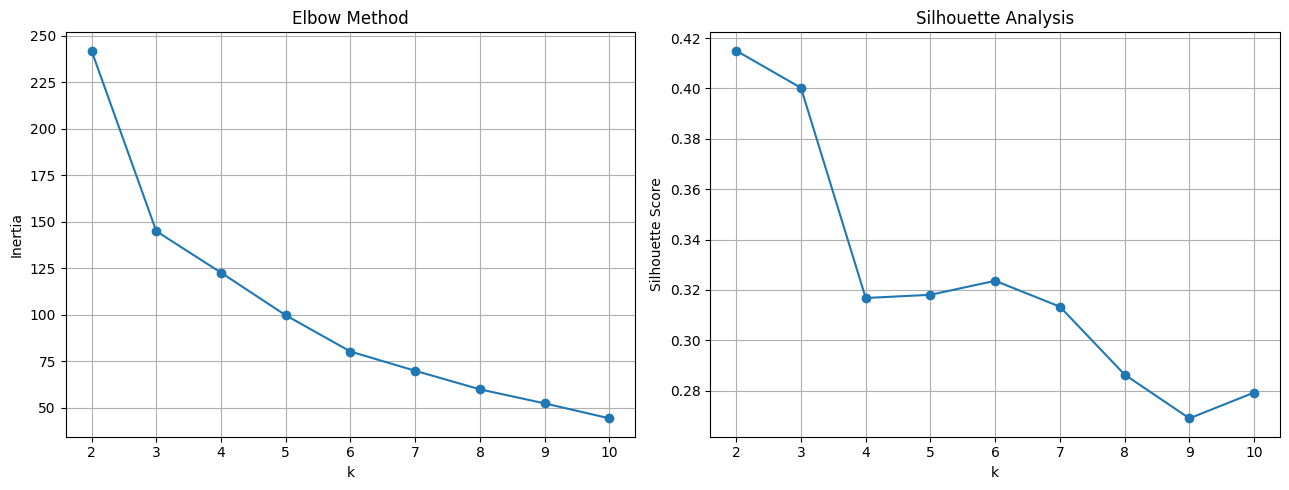

k=2: silhouette=0.415
k=3: silhouette=0.400
k=4: silhouette=0.317
k=5: silhouette=0.318
k=6: silhouette=0.324
k=7: silhouette=0.313
k=8: silhouette=0.286
k=9: silhouette=0.269
k=10: silhouette=0.279


In [ ]:
# ── SECTION 4: Elbow + Silhouette ────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = range(2, 11)
inertia, sil_scores = [], []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(k_values, inertia, marker="o")
axes[0].set(title="Elbow Method", xlabel="k", ylabel="Inertia")
axes[0].grid(True)

axes[1].plot(k_values, sil_scores, marker="o")
axes[1].set(title="Silhouette Analysis", xlabel="k", ylabel="Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

for k, s in zip(k_values, sil_scores):
    print(f"k={k}: silhouette={s:.3f}")


## K-Means Clustering

In [ ]:
# ── SECTION 5: K-Means k=3 ───────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
trajectory_features["cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster sizes:")
print(trajectory_features["cluster"].value_counts().sort_index())

print("\nCluster × Model crosstab:")
print(pd.crosstab(trajectory_features["model"],
                  trajectory_features["cluster"],
                  margins=True))

print("\nCluster means:")
print(trajectory_features.groupby("cluster")[FEATURE_COLS].mean().round(3))




Cluster sizes:
cluster
0    15
1     5
2    25
Name: count, dtype: int64

Cluster × Model crosstab:
cluster            0  1   2  All
model                           
claude-haiku-4-5  14  1   0   15
gemini-2.5-flash   1  3  11   15
gpt-4o-mini        0  1  14   15
All               15  5  25   45

Cluster means:
         mean_semantic_similarity  std_semantic_similarity  \
cluster                                                      
0                           0.874                    0.041   
1                           0.834                    0.092   
2                           0.942                    0.025   

         mean_lexical_similarity  semantic_lexical_gap  \
cluster                                                  
0                          0.568                 0.306   
1                          0.767                 0.067   
2                          0.871                 0.071   

         mean_absolute_daily_change  largest_drop  largest_recovery  \
cluster     

## Cluster Visualisation
### PCA Projection for 2D Representation

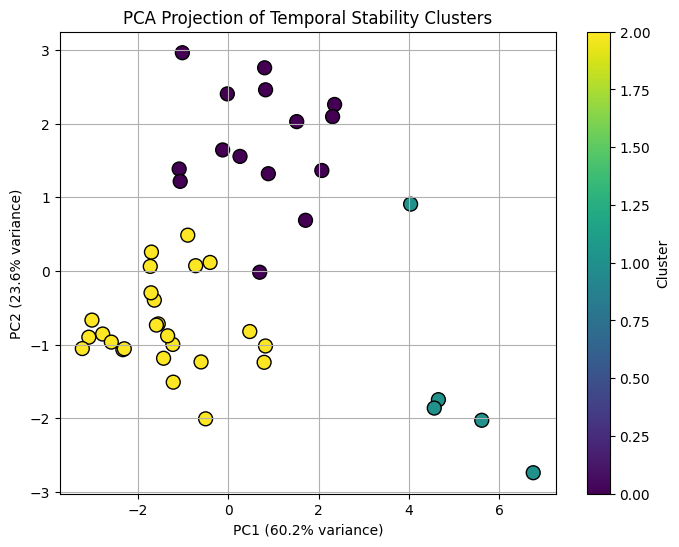

In [ ]:
# ── SECTION 6: PCA visualisation ─────────────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
trajectory_features["PC1"] = X_pca[:, 0]
trajectory_features["PC2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    trajectory_features["PC1"],
    trajectory_features["PC2"],
    c=trajectory_features["cluster"],
    cmap="viridis", s=100, edgecolor="black"
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA Projection of Temporal Stability Clusters")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

## Temporal Trajectory Visualisation
### Plotting Trajectories Grouped by Cluster

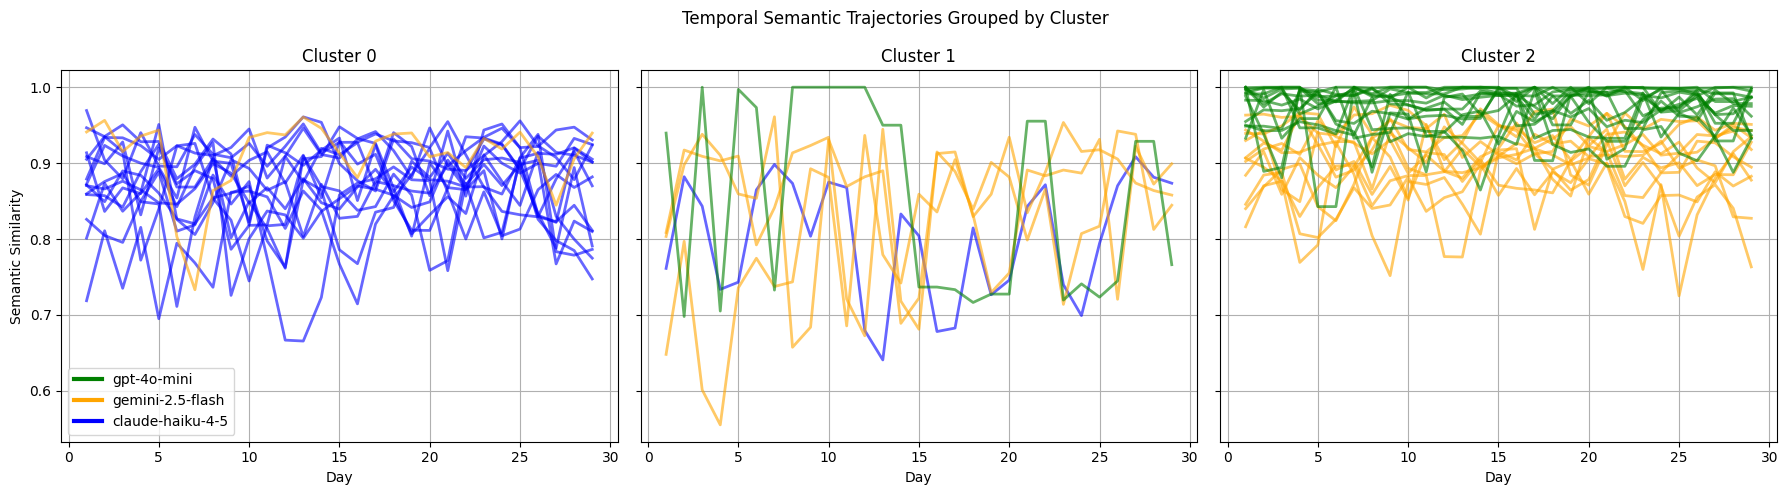

In [ ]:

# ── SECTION 7: Trajectory plots by cluster ───────────────
colors = {
    "gpt-4o-mini":     "green",
    "gemini-2.5-flash": "orange",
    "claude-haiku-4-5": "blue",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for cluster in sorted(trajectory_features["cluster"].unique()):
    ax = axes[cluster]
    rows = trajectory_features[trajectory_features["cluster"] == cluster]
    for _, row in rows.iterrows():
        traj = df[(df["model"] == row["model"]) &
                  (df["prompt_id"] == row["prompt_id"])].sort_values("day_1")
        ax.plot(traj["day_1"], traj["similarity"],
                color=colors[row["model"]], alpha=0.6, linewidth=2)
    ax.set_title(f"Cluster {cluster}")
    ax.set_xlabel("Day")
    ax.grid(True)

axes[0].set_ylabel("Semantic Similarity")
for model, color in colors.items():
    axes[0].plot([], [], color=color, linewidth=3, label=model)
axes[0].legend()

plt.suptitle("Temporal Semantic Trajectories Grouped by Cluster")
plt.tight_layout()
plt.show()


## Kruskal-Wallis H-Test for Cluster Differences

In [ ]:
# ── SECTION 8: Kruskal-Wallis (cluster validation) ───────
from scipy.stats import kruskal

groups = [trajectory_features[trajectory_features["cluster"] == c][FEATURE_COLS]
          for c in sorted(trajectory_features["cluster"].unique())]

kw_results = []
for feat in FEATURE_COLS:
    stat, p = kruskal(*[g[feat] for g in groups])
    kw_results.append({"feature": feat,
                       "H": round(stat, 3),
                       "p": round(p, 4),
                       "sig": "✓" if p < 0.05 else "✗"})

print(pd.DataFrame(kw_results).sort_values("p").to_string(index=False))


                   feature      H      p sig
  mean_semantic_similarity 23.981 0.0000   ✓
   std_semantic_similarity 21.581 0.0000   ✓
   mean_lexical_similarity 30.661 0.0000   ✓
      semantic_lexical_gap 29.135 0.0000   ✓
mean_absolute_daily_change 23.574 0.0000   ✓
          daily_change_std 21.874 0.0000   ✓
              largest_drop 17.919 0.0001   ✓
          largest_recovery 17.355 0.0002   ✓
                     trend  0.271 0.8731   ✗


The Kruskal-Wallis H-test was used to assess whether the distributions of the engineered temporal stability characteristics differed across the three identified clusters. Significant differences were observed for eight of the nine characteristics, while trend did not differ significantly between clusters (p = 0.873). This provides supporting evidence that the identified clusters exhibit distinct characteristic profiles.

## Alternative Clustering Method
### Hierarchical Clustering and Dendrogram Analysis

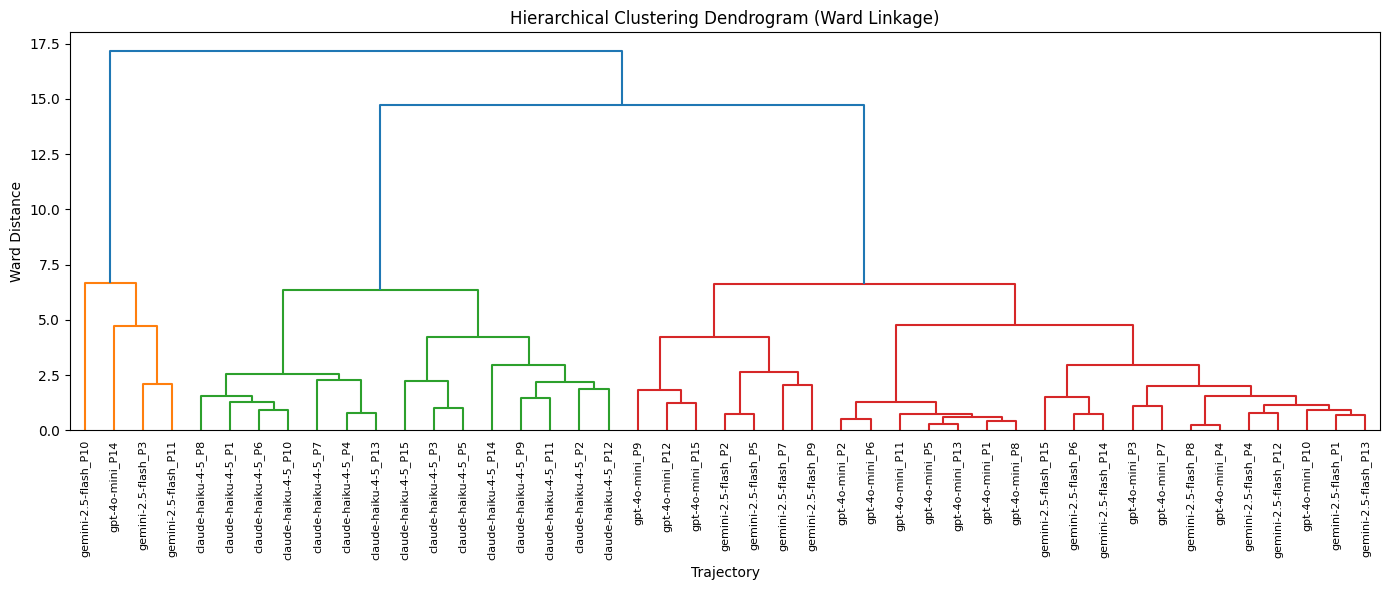


K-Means vs Agglomerative Clustering:
HC      0   1   2
KMeans           
0       0   1  14
1       4   0   1
2       0  25   0


In [ ]:
# ── SECTION 9: Ward hierarchical clustering + dendrogram ─
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

labels_list = [
    f"{m}_P{p}"
    for m, p in zip(trajectory_features["model"], trajectory_features["prompt_id"])
]

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, labels=labels_list, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Trajectory")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.show()

# Agglomerative vs K-Means comparison
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
trajectory_features["hc_cluster"] = hc.fit_predict(X_scaled)

print("\nK-Means vs Agglomerative Clustering:")
print(pd.crosstab(trajectory_features["cluster"],
                  trajectory_features["hc_cluster"],
                  rownames=["KMeans"], colnames=["HC"]))



## Random Forest Feature Importance

                   Feature  Importance
   mean_lexical_similarity    0.280487
      semantic_lexical_gap    0.260777
mean_absolute_daily_change    0.113022
  mean_semantic_similarity    0.082238
          daily_change_std    0.078734
   std_semantic_similarity    0.075413
          largest_recovery    0.054932
              largest_drop    0.046288
                     trend    0.008108


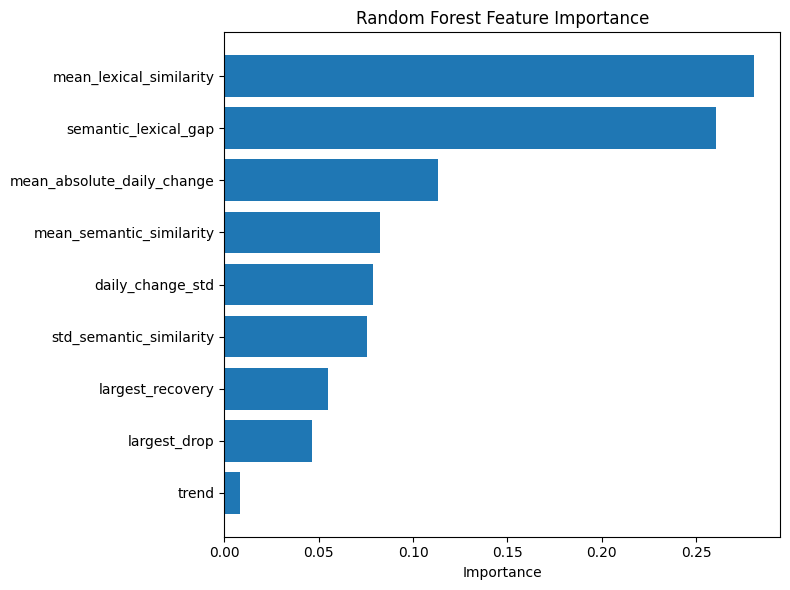

In [ ]:
# ── SECTION 10: Random Forest feature importance ──────────
from sklearn.ensemble import RandomForestClassifier

X_rf = trajectory_features[FEATURE_COLS]
y_rf = trajectory_features["cluster"]

rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_rf, y_rf)

importance = (
    pd.DataFrame({"Feature": FEATURE_COLS,
                  "Importance": rf.feature_importances_})
    .sort_values("Importance", ascending=False)
)
print(importance.to_string(index=False))

plt.figure(figsize=(8, 6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Temporal Stability Signatures

### Signature 1: Lexically Variable

K-means Cluster 0 was characterised by relatively high semantic similarity but lower lexical similarity, indicating that responses often changed in wording while maintaining similar meaning

### Signature 2: Highly Temporally Variable

K-means Cluster 1 showed the greatest temporal variability, with higher semantic variation, larger day-to-day changes, and the largest drops and recoveries. This represents trajectories with substantial fluctuations over time.

### Signature 3: Highly Temporally Stable

K-means Cluster 2 was characterised by high semantic and lexical similarity, together with low variation and smaller day-to-day changes. This indicates strong stability in both meaning and wording across time.